In [29]:
from src.evaluation import compute_max_swaps_count, compute_structural_depth, compute_quantum_depth
import math

In [ ]:
import os
import matplotlib.pyplot as plt

# Load files from results_sabre directory
results_dir = 'results/16qbt'
sabre_dir = 'results_sabre/16qbt'
files = []
for root, dirs, filenames in os.walk(results_dir):
    for f in filenames:
        if f.endswith('.json') :
            files.append(os.path.join(root, f))

sabre_files = []
for root, dirs, filenames in os.walk(sabre_dir):
    for f in filenames:
        if f.endswith('.json') :
            sabre_files.append(os.path.join(root, f))

max_swaps = []
quantum_depths = []
file_names = []

max_swaps_sabre = []
quantum_depths_sabre = []
file_names_sabre = []

NB_LOOP_ITERATIONS = 100
USE_LOG_SCALE = False

# Process each file
for file in files:
    file_path = file

    # load json into dict named trace
    import json
    with open(file_path, 'r') as f:
        trace = json.load(f) 
    # Compute metrics
    swaps = compute_max_swaps_count(trace,loop_iterations=NB_LOOP_ITERATIONS)
    if USE_LOG_SCALE:
        swaps = 0 if swaps == 0 else round(math.log2(swaps))
    depth = compute_quantum_depth(trace,loop_iterations=NB_LOOP_ITERATIONS)
    if USE_LOG_SCALE:
        depth = 0 if depth == 0 else round(math.log2(depth))

    max_swaps.append(swaps)
    quantum_depths.append(depth)
    file_names.append(file)

for file in sabre_files:
    file_path = file

    # load json into dict named trace
    import json
    with open(file_path, 'r') as f:
        trace = json.load(f) 
    # Compute metrics
    swaps = compute_max_swaps_count(trace,loop_iterations=NB_LOOP_ITERATIONS)
    if USE_LOG_SCALE:
        swaps = 0 if swaps == 0 else round(math.log2(swaps))
    depth = compute_quantum_depth(trace,loop_iterations=NB_LOOP_ITERATIONS)
    if USE_LOG_SCALE:
        depth = 0 if depth == 0 else round(math.log2(depth))

    max_swaps_sabre.append(swaps)
    quantum_depths_sabre.append(depth)
    file_names_sabre.append(file)

In [21]:
max_swaps[1], max_swaps_sabre[1]

(2601141, 3020611)

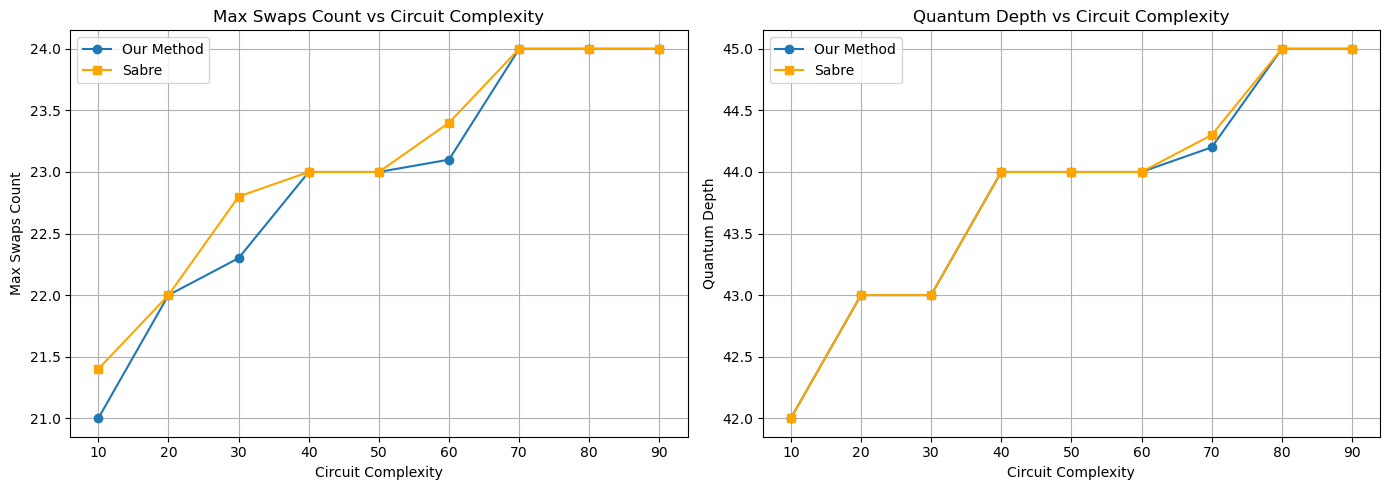

In [34]:
import numpy as np

# Group files by their parent directory (leaf-depth level)
leaf_depth_groups = {}
leaf_depth_groups_sabre = {}
for i, file in enumerate(file_names):
    # Extract leaf-depth value from path (e.g., 'leaf-depth-10')
    parts = file.split('\\')
    for part in parts:
        if 'leaf-depth-' in part:
            leaf_depth = int(part.split('leaf-depth-')[-1])
            if leaf_depth not in leaf_depth_groups:
                leaf_depth_groups[leaf_depth] = {'swaps': [], 'depths': []}
            leaf_depth_groups[leaf_depth]['swaps'].append(max_swaps[i])
            leaf_depth_groups[leaf_depth]['depths'].append(quantum_depths[i])
            break
for i, file in enumerate(file_names_sabre):
    # Extract leaf-depth value from path (e.g., 'leaf-depth-10')
    parts = file.split('\\')
    for part in parts:
        if 'leaf-depth-' in part:
            leaf_depth = int(part.split('leaf-depth-')[-1])
            if leaf_depth not in leaf_depth_groups_sabre:
                leaf_depth_groups_sabre[leaf_depth] = {'swaps': [], 'depths': []}
            leaf_depth_groups_sabre[leaf_depth]['swaps'].append(max_swaps_sabre[i])
            leaf_depth_groups_sabre[leaf_depth]['depths'].append(quantum_depths_sabre[i])
            break

# Calculate averages
leaf_depths_sorted = sorted(leaf_depth_groups.keys())
avg_swaps = [np.mean(leaf_depth_groups[ld]['swaps']) for ld in leaf_depths_sorted]
avg_depths = [np.mean(leaf_depth_groups[ld]['depths']) for ld in leaf_depths_sorted]

leaf_depths_sorted_sabre = sorted(leaf_depth_groups_sabre.keys())
avg_swaps_sabre = [np.mean(leaf_depth_groups_sabre[ld]['swaps']) for ld in leaf_depths_sorted_sabre]
avg_depths_sabre = [np.mean(leaf_depth_groups_sabre[ld]['depths']) for ld in leaf_depths_sorted_sabre]
# Plot the results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot both datasets on the same axes for comparison
ax1.plot(leaf_depths_sorted, avg_swaps, marker='o', label='Our Method')
ax1.plot(leaf_depths_sorted_sabre, avg_swaps_sabre, marker='s', color='orange', label='Sabre')
ax1.set_xlabel('Circuit Complexity')
ax1.set_ylabel('Max Swaps Count')
ax1.set_title('Max Swaps Count vs Circuit Complexity')
ax1.legend()
ax1.grid(True)

ax2.plot(leaf_depths_sorted, avg_depths, marker='o', label='Our Method')
ax2.plot(leaf_depths_sorted_sabre, avg_depths_sabre, marker='s', color='orange', label='Sabre')
ax2.set_xlabel('Circuit Complexity')
ax2.set_ylabel('Quantum Depth')
ax2.set_title('Quantum Depth vs Circuit Complexity')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


Text(0.5, 0, 'Circuit Complexity')

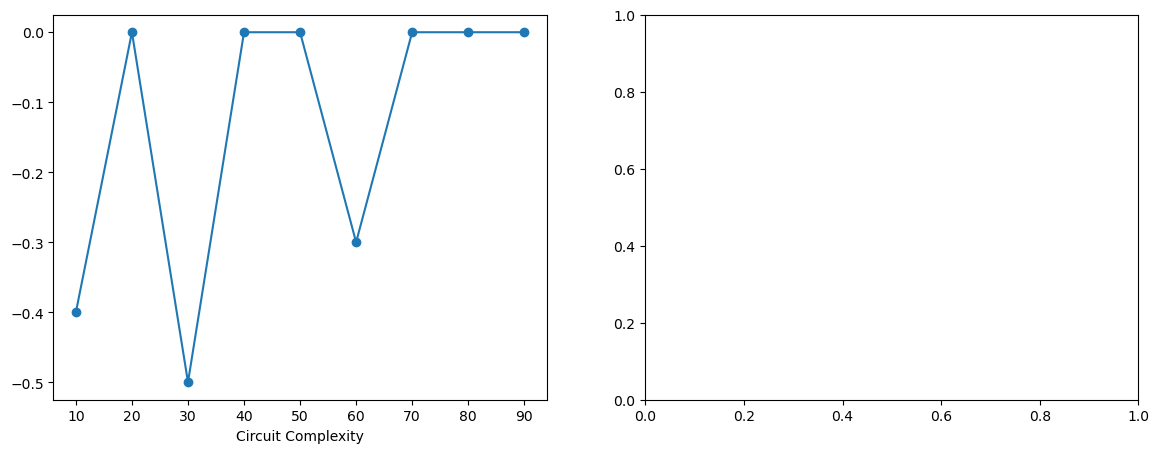

In [35]:
# plot difference between both methods
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# Plot both datasets on the same axes for comparison
ax1.plot(leaf_depths_sorted, np.array(avg_swaps)-np.array(avg_swaps_sabre), marker='o', label='Our Method - Sabre')
ax1.set_xlabel('Circuit Complexity')